In [ ]:
import importlib
import NeuralNetwork
import funcs

importlib.reload(NeuralNetwork)
importlib.reload(funcs)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import defaultdict
import numpy as np
from tqdm import tqdm
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device being used: {device.type}")

device being used: cuda


## Global parameters

In [3]:
# model parameters
HIDDEN_LAYERS = [512, 256, 128, 64]
TRAIN_VAL_SPLIT = 0.8

# initial training
N_TRAIN_EPOCHS = 15 if device.type == "cuda" else 8

# pruning loop
MAX_ALLOWED_ACC_DROP = 0.02
MAX_PRUNE_ROUNDS = 10
PRUNE_FRAC = 0.05
REGROW_FRAC = 0.1
MIN_VAL_ACC = 0.9
N_RETRIAN_EPOCHS = 3

# clustering
N_CLUSTERS = 15

## Setting up data and initial model

In [4]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.rot90(x, k=-1, dims=[1,2])),
    transforms.Lambda(lambda x: torch.flip(x, dims=[2]))
])

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [5]:
train_size = int(TRAIN_VAL_SPLIT * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
print(f"train size: {train_size}, val size: {val_size}, test size: {len(test_dataset)}")

train size: 192000, val size: 48000, test size: 40000


In [6]:
# Create a DataLoader for batching
batch_size = 256 if device.type == "cuda" else 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
# Create model and train
model = NeuralNetwork(hidden_sizes=HIDDEN_LAYERS, device=device)

In [ ]:

if os.path.exists("full_model.pth"):
    full_model = torch.load("full_model.pth")
    full_model.eval()
    print("Loaded model from disk.")
else:   
    metrics = model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=N_TRAIN_EPOCHS)
    torch.save(model, "full_model.pth")
    print("Model trained and saved")
    print(metrics)

Early stopping triggered at epoch 8
       train_loss  train_acc  val_loss   val_acc
epoch                                           
1        0.295487   0.938224  0.095988  0.972479
2        0.183014   0.972156  0.110114  0.968500
3        0.176381   0.973594  0.090339  0.974083
4        0.168791   0.974609  0.092472  0.973000
5        0.165249   0.975078  0.087760  0.975437
6        0.163815   0.975432  0.093383  0.974104
7        0.162465   0.975646  0.088198  0.975354
8        0.160883   0.976354  0.101554  0.970417


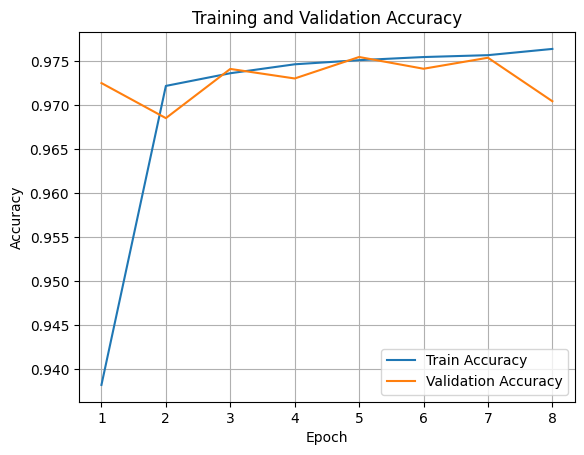

In [9]:
funcs.plot_accuracy(metrics)

## Prune Neurons and Retrain

In [ ]:
prune_parameters = (MAX_PRUNE_ROUNDS, PRUNE_FRAC, REGROW_FRAC, N_RETRIAN_EPOCHS, MAX_ALLOWED_ACC_DROP)
use_max_rounds = False if device.type == "cuda" else True

if os.path.exists("pruned_model.pth"):
    final_model = torch.load("pruned_model.pth")
    final_model.eval()  # Set to evaluation mode if only doing inference
    print("Loaded model from disk.")
else:
    final_model, final_val_acc, metrics_history = funcs.pruning(model, train_loader, val_loader, prune_parameters, use_max_rounds)
    torch.save(final_model, "pruned_model.pth")
    print("Pruned model saved!")


--- Pruning round 17 ---
Getting layer data:


100%|██████████| 750/750 [00:13<00:00, 57.57it/s]


Retraining:


KeyboardInterrupt: 

In [ ]:
for round_idx, metrics in enumerate(metrics_history, start=1):
    print(f"--- Round {round_idx} ---")
    final_val_acc = metrics['val_acc'].iloc[-1]
    print(f"Final validation accuracy: {final_val_acc:.5f}")

--- Round 1 ---
Final validation accuracy: 0.97715
--- Round 2 ---
Final validation accuracy: 0.97452
--- Round 3 ---
Final validation accuracy: 0.97681
--- Round 4 ---
Final validation accuracy: 0.97754
--- Round 5 ---
Final validation accuracy: 0.97671
--- Round 6 ---
Final validation accuracy: 0.97408
--- Round 7 ---
Final validation accuracy: 0.97752
--- Round 8 ---
Final validation accuracy: 0.97302
--- Round 9 ---
Final validation accuracy: 0.97550
--- Round 10 ---
Final validation accuracy: 0.97077
--- Round 11 ---
Final validation accuracy: 0.97644
--- Round 12 ---
Final validation accuracy: 0.97825
--- Round 13 ---
Final validation accuracy: 0.97817
--- Round 14 ---
Final validation accuracy: 0.97627
--- Round 15 ---
Final validation accuracy: 0.97160
--- Round 16 ---
Final validation accuracy: 0.96956
--- Round 17 ---
Final validation accuracy: 0.96808
--- Round 18 ---
Final validation accuracy: 0.96519
--- Round 19 ---
Final validation accuracy: 0.95656


In [ ]:
print(f"Test accuracy after pruning: {final_model.accuracy(test_loader)*100:.2f}")

100%|██████████| 157/157 [00:02<00:00, 69.53it/s]

Test accuracy after pruning: 96.55


## Activation analysis and Neuron Clustering

We create a new data loader that does not shuffle the data so our instances match up with our data

In [ ]:
analysis_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
layer_data_analysis = final_model.get_layer_data(analysis_loader)

100%|██████████| 750/750 [00:11<00:00, 66.08it/s]


In [ ]:
for key, value in layer_data_analysis.items():
    print(f"{key} has shape: {value['post_activation'].shape}")

layer_0 has shape: torch.Size([192000, 18])
layer_1 has shape: torch.Size([192000, 12])
layer_2 has shape: torch.Size([192000, 10])


In [ ]:
hidden_layers = [k for k in layer_data_analysis.keys() if 'layer_' in k]

all_neuron_activations = []
for layer_name in hidden_layers:
    acts = layer_data_analysis[layer_name]['post_activation']
    all_neuron_activations.append(acts)

all_neuron_activations = torch.cat(all_neuron_activations, dim=1)

In [ ]:
layer_mapping = []
start_idx = 0
for layer_name in hidden_layers:
    n_neurons = layer_data_analysis[layer_name]['post_activation'].shape[1]
    end_idx = start_idx + n_neurons
    layer_mapping.append((layer_name, start_idx, end_idx))
    start_idx = end_idx

In [ ]:
labels = []
images = []
for X, y in tqdm(analysis_loader):
    labels.append(y)
    images.append(X)
labels = torch.cat(labels, dim=0)
images = torch.cat(images, dim=0)

100%|██████████| 750/750 [00:09<00:00, 79.58it/s]


## Clustering

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

neurons_for_clustering = all_neuron_activations.T.numpy()

Z = linkage(neurons_for_clustering, method='ward', metric='euclidean')

n_clusters = N_CLUSTERS
clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

print(f"Total neurons clustered: {neurons_for_clustering.shape[0]}")
print(f"Clusters assigned: {np.unique(clusters)}")

Total neurons clustered: 40
Clusters assigned: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [ ]:
cluster_map = defaultdict(list)
for neuron_idx, cluster_id in enumerate(clusters):
    cluster_map[cluster_id].append(neuron_idx)

## Cluster selectivity analysis

In [ ]:
selectivity_results = funcs.compute_cluster_selectivity(cluster_map, all_neuron_activations, labels)

c:\Users\iweyn\Documents\Coding\Project-ML\funcs.py:265: RuntimeWarning: invalid value encountered in log
  entropy = -np.sum(prob_dist*np.log(prob_dist+1e-12))


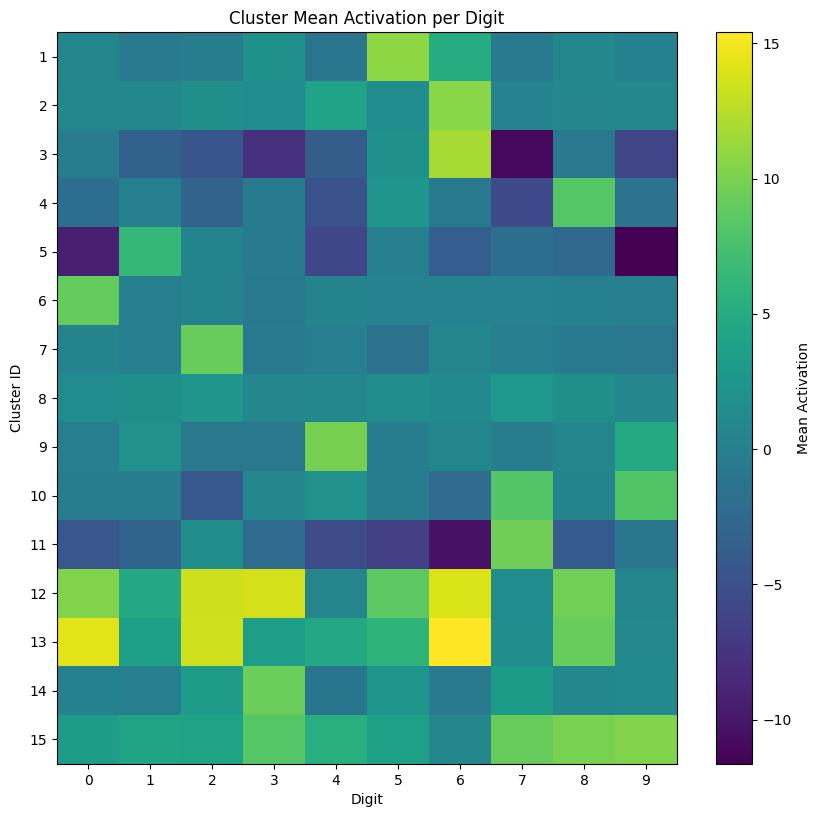

In [ ]:
funcs.plot_cluster_activation_heatmap(selectivity_results)

## Cluster ablation

In [ ]:
cluster_results = {}
for cluster_id, neuron_indices in cluster_map.items():
    per_class_acc = funcs.cluster_criticality_per_class(
        final_model,
        neuron_indices,
        layer_mapping,
        val_loader,
        cluster_id,
        device=device
    )
    cluster_results[cluster_id] = per_class_acc


--- Calculating pre and post-ablation accuracy for cluster 4 ---


100%|██████████| 188/188 [00:02<00:00, 72.95it/s]


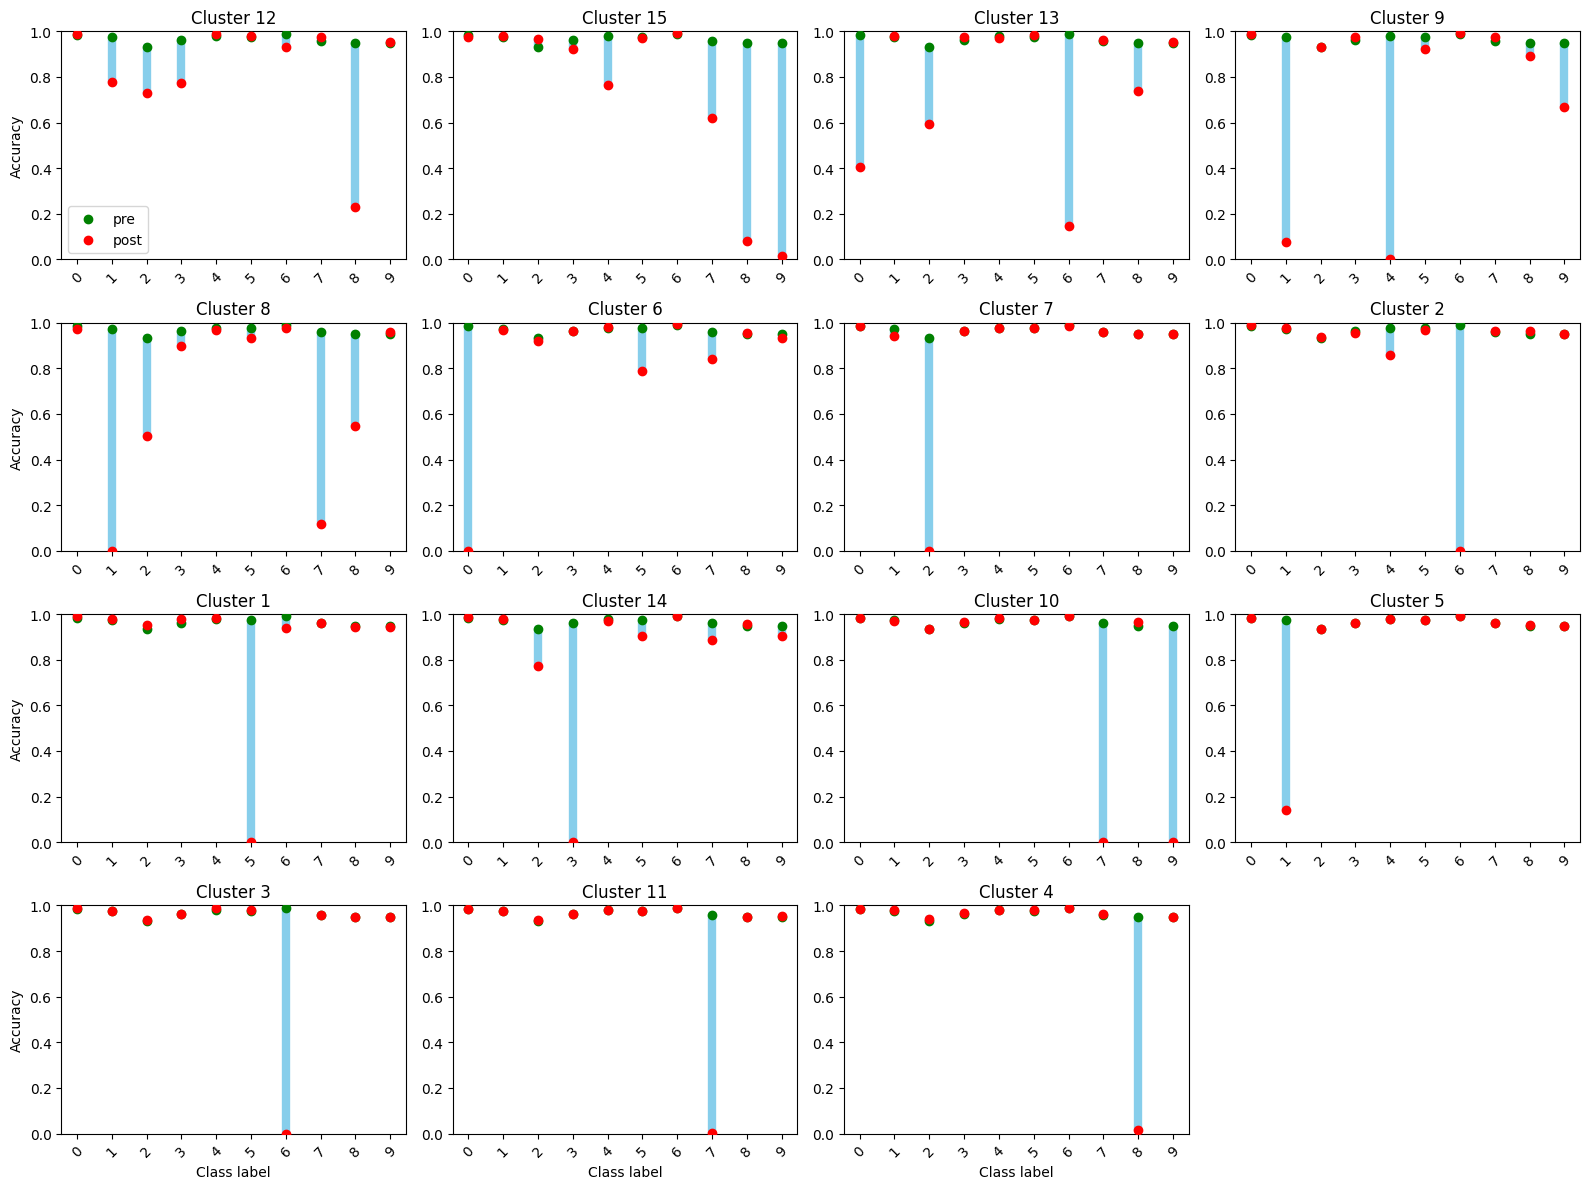

In [ ]:
cluster_class_changes = funcs.plot_cluster_accuracy_bars(cluster_results, target_labels=list(range(10)))

## Prototype and difference map plots

In [ ]:
# Compute prototypes and difference maps for all clusters
all_prototypes = funcs.compute_prototypes_all_clusters(
    cluster_map=cluster_map,
    all_activations=all_neuron_activations,
    images=images,
    top_frac=0.1,           # fraction of top-activating samples per cluster
    use_global_mean=True     # normalize diff map relative to global mean
)

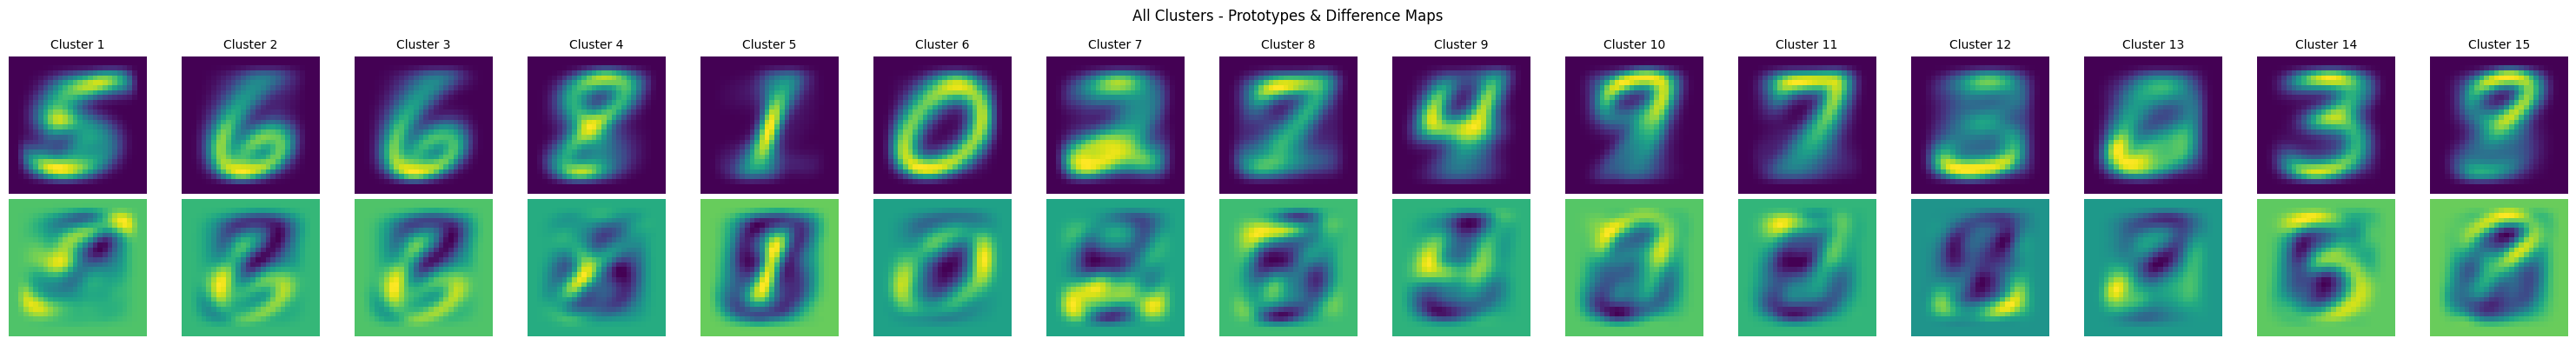

In [ ]:
funcs.plot_cluster_prototypes_and_diff_all(all_prototypes)

## cluster extraction